# 🚗 Car Detection with TensorFlow (SSD MobileNet V2)

> **Goal:** Replicate the same car-detection pipeline from the Haar Cascade lab, but using a modern **deep-learning** approach powered by TensorFlow and a pre-trained **SSD MobileNet V2** model from TensorFlow Hub.

---

## 🔄 Haar Cascade vs TensorFlow — What changes and why?

| Aspect | Haar Cascade (Original) | TensorFlow SSD MobileNet (This Lab) |
|---|---|---|
| **Method** | Hand-crafted Haar wavelet features | Deep CNN learned from millions of images |
| **Input** | Grayscale image | RGB image (colour matters!) |
| **Output** | Bounding boxes only | Boxes + class labels + confidence scores |
| **Car-only?** | Yes (trained only for cars) | No — detects 90 COCO classes; we filter for `car` |
| **Speed** | Very fast (classical CV) | Slower, but more accurate |
| **False positives** | Frequent (needs tuning) | Much fewer |

---

## 📋 Table of Contents

1. [Install & Import Libraries](#1-install--import-libraries)
2. [Helper Functions](#2-helper-functions)
3. [Load the Model](#3-load-the-model)
4. [Load & Display the Image](#4-load--display-the-image)
5. [Run Detection](#5-run-detection)
6. [Practice Exercise — Try Your Own Image](#6-practice-exercise--try-your-own-image)


## 1. Install & Import Libraries

We need three main packages on top of the standard Python stack:

| Package | Role |
|---|---|
| `tensorflow` | Core deep-learning framework (replaces OpenCV's cascade engine) |
| `tensorflow-hub` | One-line loader for pre-trained models (replaces the XML download) |
| `opencv-python-headless` | Used for **drawing** bounding boxes & image I/O (not for detection) |
| `numpy`, `matplotlib` | Numerical ops and visualisation — same as before |

> ⚠️ **Why keep OpenCV?** The original lab used it for `cv2.rectangle()` and `cv2.imread()`.
> We keep those utilities so the drawing/display code stays familiar.


In [1]:
# Install required packages (run once; restart kernel if needed)
!pip install tensorflow tensorflow-hub opencv-python-headless numpy matplotlib --quiet


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\User\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



In [2]:
import urllib.request
import numpy as np
import cv2
import tensorflow as tf
import tensorflow_hub as hub
from matplotlib import pyplot as plt
%matplotlib inline

print(f"TensorFlow version : {tf.__version__}")
print(f"TensorFlow Hub     : {hub.__version__}")


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



TensorFlow version : 2.21.0
TensorFlow Hub     : 0.16.1


## 2. Helper Functions

We keep the same `plt_show()` signature as the original lab so the display behaviour is identical.
We then add two new helpers specific to TF models.


### 2a. `plt_show()` — Display an image

Identical to the original lab:
- Converts **BGR → RGB** (OpenCV loads BGR; matplotlib expects RGB).
- Accepts an optional `gray` flag for single-channel display.


In [3]:
def plt_show(image, title="", gray=False, size=(10, 10)):
    """Display an image with matplotlib. Mirrors the original lab utility."""
    temp = image.copy()

    if not gray:
        # OpenCV stores images as BGR; matplotlib needs RGB
        temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=size)
    plt.imshow(temp, cmap='gray' if gray else None)
    plt.title(title)
    plt.axis("off")
    plt.show()


### 2b. `preprocess_image()` — Prepare image for the TF model

**Why this step?**
Haar cascades expected a **grayscale** NumPy array.
SSD MobileNet V2 expects a **uint8 RGB tensor** with shape `[1, H, W, 3]`
(the leading `1` is the batch dimension — the model needs to know how many images you're sending).

```
Original lab:           gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
TensorFlow equivalent:  rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        tensor = tf.expand_dims(rgb, axis=0)   # add batch dim
```


In [4]:
def preprocess_image(bgr_image):
    """
    Convert an OpenCV BGR image into a uint8 RGB tensor ready for TF Hub models.

    Steps:
      1. BGR -> RGB  (colour channel reorder)
      2. Add batch dimension: (H, W, 3) -> (1, H, W, 3)
      3. Cast to uint8  (SSD MobileNet V2 requires uint8, NOT float32)

    Returns:
        tf.Tensor of shape [1, H, W, 3], dtype=tf.uint8
    """
    rgb    = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)   # Step 1
    tensor = tf.expand_dims(rgb, axis=0)                   # Step 2
    tensor = tf.cast(tensor, dtype=tf.uint8)               # Step 3
    return tensor


### 2c. `detect_obj()` — The main detection function

This is the TensorFlow equivalent of `detect_obj()` from the original lab.

**Key differences from the Haar version:**

| Step | Haar Cascade | TensorFlow SSD |
|---|---|---|
| Grayscale conversion | ✅ Required | ❌ Not needed (uses RGB) |
| `detectMultiScale()` | Classical feature scan | `detector(tensor)` — forward pass through CNN |
| Output format | List of `(x, y, w, h)` | Dict with `detection_boxes`, `detection_scores`, `detection_classes` |
| Class filtering | N/A (car-only model) | Filter by `class_id == 3` (COCO id for "car") |
| Confidence threshold | `minNeighbors` controls it | Explicit `score_threshold` parameter |

> **COCO class IDs start at 1.**
> Class 3 = `car` in the COCO 2017 label map used by MobileNet models.


In [11]:
# COCO label map (partial — the vehicle classes most relevant here)
COCO_LABELS = {
    1: "person",  2: "bicycle", 3: "car",   4: "motorcycle",
    5: "airplane",6: "bus",     7: "train", 8: "truck",
    9: "boat"
}


In [ ]:

def detect_obj(bgr_image, score_threshold=0.3):
    """
    Detect cars in a BGR image using SSD MobileNet V2.

    Equivalent to the Haar-based detect_obj() in the original lab, but:
      - Works in RGB colour space (not grayscale)
      - Filters by COCO class id 3 (car) and confidence score
      - Draws labelled boxes with confidence % instead of plain green rectangles

    Args:
        bgr_image       : OpenCV BGR image (numpy array)
        score_threshold : Minimum confidence to accept a detection (0-1)
                          Equivalent to tuning minNeighbors in the Haar version
    """
    img_copy = bgr_image.copy()
    h, w = img_copy.shape[:2]

    # ── Step 1: Preprocess ──────────────────────────────────────────────────
    # Haar: gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # TF  : convert to RGB tensor with batch dimension
    input_tensor = preprocess_image(bgr_image)

    # ── Step 2: Run the model ───────────────────────────────────────────────
    # Haar: cars = detector.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=2, ...)
    # TF  : result = detector(input_tensor)  — one CNN forward pass
    result = detector(input_tensor)

    # ── Step 3: Unpack results ──────────────────────────────────────────────
    # Boxes are NORMALISED [ymin, xmin, ymax, xmax] — values 0 to 1 (not pixels yet)
    boxes   = result["detection_boxes"].numpy()[0]    # shape: (N, 4)
    scores  = result["detection_scores"].numpy()[0]   # shape: (N,)
    classes = result["detection_classes"].numpy()[0]  # shape: (N,)  float

    # ── Step 4: Filter — keep only high-confidence cars ────────────────────
    # class 3 = car in COCO; change to `int(cls) in (3, 8)` to also catch trucks
    car_detections = [
        (boxes[i], scores[i], int(classes[i]))
        for i in range(len(scores))
        if scores[i] >= score_threshold and int(classes[i]) == 3
    ]

    # ── Step 5: Mirror original lab — keep only the highest-confidence box ─
    # Original: cars = sorted(..., key=lambda box: box[2]*box[3], reverse=True); cars=[cars[0]]
    if len(car_detections) > 1:
        car_detections = sorted(car_detections, key=lambda x: x[1], reverse=True)
        car_detections = [car_detections[0]]   # top-1 detection

    print(f"Detected: {len(car_detections)} car(s)")

    # ── Step 6: Draw bounding boxes ─────────────────────────────────────────
    for (box, score, cls_id) in car_detections:
        ymin, xmin, ymax, xmax = box

        # Convert normalised coords -> pixel coords
        x1 = int(xmin * w);  y1 = int(ymin * h)
        x2 = int(xmax * w);  y2 = int(ymax * h)

        label = COCO_LABELS.get(cls_id, str(cls_id))
        text  = f"{label}: {score:.0%}"

        # Green rectangle — same colour as the original lab
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Label background + text (extra info not in the original)
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img_copy, (x1, y1 - th - 10), (x1 + tw, y1), (0, 255, 0), -1)
        cv2.putText(img_copy, text, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    plt_show(img_copy, title="Detected Car (TensorFlow SSD MobileNet V2)")


## 3. Load the Model

**Original lab:**
```python
# Step 1 — download XML manually
urllib.request.urlretrieve(haarcascade_url, haar_name)
# Step 2 — create the classifier
detector = cv2.CascadeClassifier(haar_name)
```

**TensorFlow equivalent — one line does both:**
```python
detector = hub.load(MODEL_URL)
```

We use **SSD MobileNet V2** trained on **COCO 2017** (90 object classes including cars).
It is fast, lightweight, and already knows what cars look like — no XML file needed.

> 📦 The model (~30 MB) is downloaded and cached on first run.
> Subsequent runs load from cache almost instantly.


In [6]:
# SSD MobileNet V2 pre-trained on COCO 2017
# TF Hub page: https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2
MODEL_URL = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"

print("Loading model from TensorFlow Hub (first run may take ~30 s)...")
detector = hub.load(MODEL_URL)
print("Model loaded successfully!")


Loading model from TensorFlow Hub (first run may take ~30 s)...



Model loaded successfully!


## 4. Load & Display the Image

Same image URL as the original lab — the pipeline difference starts at
**how we feed the image to the model**, not at how we load it.


Image shape: (444, 600, 3)   (Height x Width x Channels)


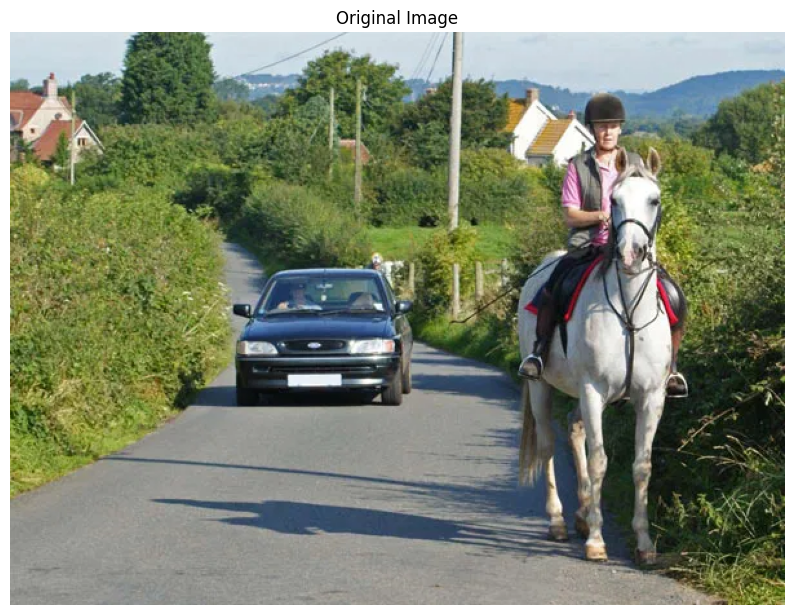

In [7]:
# Same image as the original lab
image_url  = "https://s3.us.cloud-object-storage.appdomain.cloud/cf-courses-data/CognitiveClass/CV0101/Dataset/car-road-behind.jpg"
image_name = "car-road-behind.jpg"

urllib.request.urlretrieve(image_url, image_name)

# Load with OpenCV — same as before (returns a BGR NumPy array)
image = cv2.imread(image_name)

print(f"Image shape: {image.shape}   (Height x Width x Channels)")
plt_show(image, title="Original Image")


## 5. Run Detection

This single call mirrors `detect_obj(image)` in the original lab.
Everything that was done by `detectMultiScale()` is now handled inside
the TensorFlow model in one forward pass.


Detected: 1 car(s)


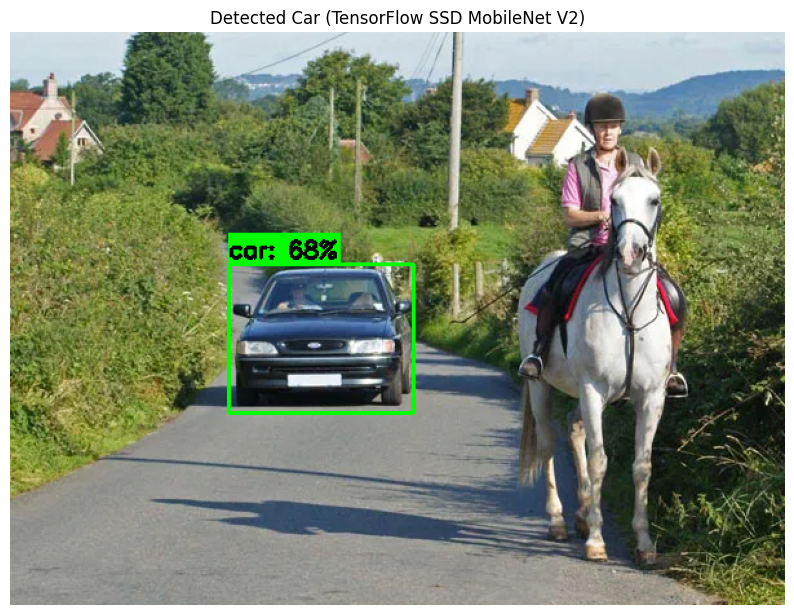

In [8]:
detect_obj(image)


### What just happened under the hood?

```
BGR image (loaded from disk)
      │
      ▼  cv2.cvtColor(BGR -> RGB)       ← replaces: cv2.cvtColor(BGR -> GRAY)
      │
      ▼  tf.expand_dims(axis=0)         ← adds batch dim: [H,W,3] -> [1,H,W,3]
      │
      ▼  detector(tensor)               ← replaces: detector.detectMultiScale()
      │                                    One CNN forward pass through the network
      │
      ├─▶ detection_boxes   [N, 4]   normalised (ymin, xmin, ymax, xmax)
      ├─▶ detection_scores  [N]      confidence 0 -> 1
      └─▶ detection_classes [N]      COCO class id (3 = car)
                 │
                 ▼  filter: class == 3 AND score >= 0.3
                 │
                 ▼  keep top-1 box  (mirrors original lab behaviour)
                 │
                 ▼  convert normalised coords -> pixel coords
                 │
                 ▼  draw green rectangle + confidence label
```


## 6. Practice Exercise — Try Your Own Image

Same exercise as the original lab: download the sample images or upload
your own, then run the TF detector on them.


In [9]:
# Download the same sample images from the original lab
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/h3EzuZiidvgdOxPA_yVVWg/car1.jpg"
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eKnqJ2xWDdanVdLH6WgOmQ/car2.jpg"
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/JDjRn_0f5kx9DRT2xv_mew/nocar.jpg"
print("Images downloaded.")


'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


Images downloaded.


'wget' is not recognized as an internal or external command,
operable program or batch file.


Detected: 1 car(s)


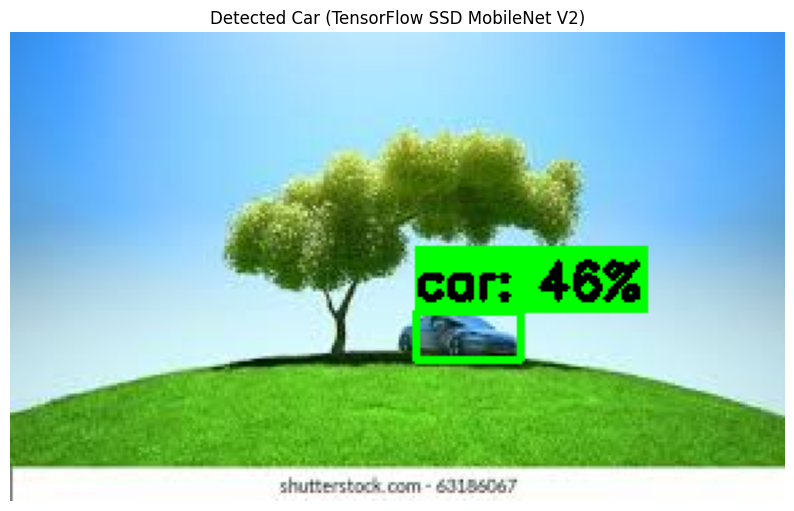

In [10]:
# Replace "car2.jpg" with your own uploaded file name if needed
my_image = cv2.imread("car2.jpg")

if my_image is None:
    print("Error: image is empty or not loaded properly.")
else:
    detect_obj(my_image)


### Tuning tip — adjusting the confidence threshold

In the original lab you tuned `minNeighbors` to reduce false positives.
In TensorFlow you tune `score_threshold` instead:

```python
detect_obj(my_image, score_threshold=0.5)   # stricter — fewer but more confident boxes
detect_obj(my_image, score_threshold=0.2)   # looser  — more boxes, may include false positives
```


---

## Congratulations!

You have converted a classical **Haar Cascade** car-detection pipeline into a
modern **TensorFlow deep-learning** pipeline.

| Step | Haar version | TF version |
|---|---|---|
| Download model | `urllib` → XML file | `hub.load()` → CNN weights |
| Pre-process image | BGR → Grayscale | BGR → RGB tensor [1, H, W, 3] |
| Run detection | `detectMultiScale()` | `detector(tensor)` |
| Parse output | `(x, y, w, h)` tuples | Dict with boxes, scores, classes |
| Filter results | `minNeighbors`, `minSize` | `score_threshold`, `class_id == 3` |
| Display result | `plt_show()` | Same `plt_show()` |
